In [5]:
# Name: Eshwar Lal
# Student ID: 023-24-0186
# Section: F
# GitHub Profile: https://github.com/Eshwarlal-125/Machine_Learning_Course
# Kaggle Profile: https://www.kaggle.com/mreshwar
# Dataset: House Prices - Advanced Regression Techniques
# Dataset Source: Kaggle

In [6]:
# Task:01
import pandas as pd

df = pd.read_csv("clean_churn.csv")

print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

Shape: (7043, 20)

Data Types:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [7]:
# Task:02
# The Decision Tree and Random Forest results from Labs 3–4 
# are used as benchmarks. These results allow us to compare the 
# new Logistic Regression and KNN models fairly on the same churn
# prediction problem.

In [8]:
# Task:03
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df = df.drop(columns=["customerID"], errors="ignore")

df = pd.get_dummies(df, drop_first=True)

X = df.drop(columns=["Churn"])
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 30)
y shape: (7043,)


In [9]:
# Task:04


In [10]:
# Task:05
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("clean_churn.csv")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df = df.drop(columns=["customerID"], errors="ignore")

df = pd.get_dummies(df, drop_first=True)

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [11]:
# Task:06
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

Accuracy : 0.8069552874378992
Precision: 0.6583850931677019
Recall   : 0.5668449197860963
F1-Score : 0.6091954022988506


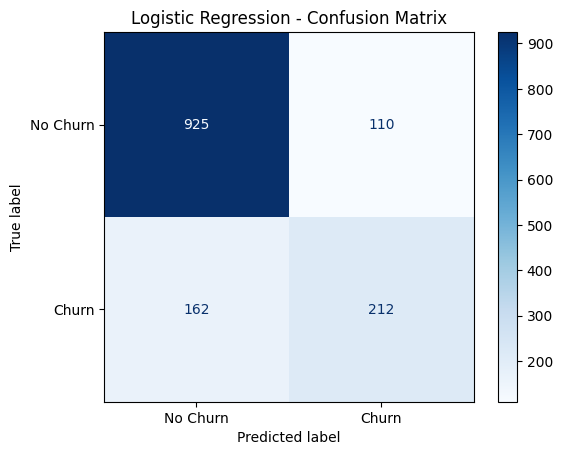

In [12]:
# Task:07
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1-Score :", f1_score(y_test, y_pred_lr))

cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["No Churn", "Churn"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Logistic Regression - Confusion Matrix")
plt.show()


In [13]:
# Task:08
probs = log_reg.predict_proba(X_test_scaled[:5])

for i, p in enumerate(probs):
    print(f"Customer {i+1}: P(No Churn) = {p[0]:.3f}, P(Churn) = {p[1]:.3f}")

Customer 1: P(No Churn) = 0.955, P(Churn) = 0.045
Customer 2: P(No Churn) = 0.317, P(Churn) = 0.683
Customer 3: P(No Churn) = 0.943, P(Churn) = 0.057
Customer 4: P(No Churn) = 0.592, P(Churn) = 0.408
Customer 5: P(No Churn) = 0.978, P(Churn) = 0.022


In [14]:
# Task:09
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

k_values = [1, 3, 5, 7, 9, 11, 15, 21]
results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_knn = knn.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred_knn)
    f1 = f1_score(y_test, y_pred_knn)
    results.append({"K": k, "Accuracy": acc, "F1-Score": f1})

results_df = pd.DataFrame(results)
print(results_df)

    K  Accuracy  F1-Score
0   1  0.716111  0.476440
1   3  0.743790  0.512821
2   5  0.747339  0.512329
3   7  0.759404  0.532414
4   9  0.769340  0.557823
5  11  0.772889  0.561644
6  15  0.770050  0.554945
7  21  0.770759  0.561737


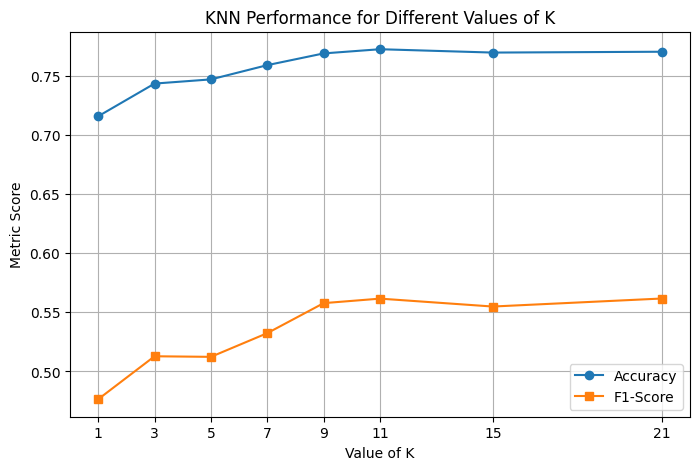

In [15]:
# Task:10
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(results_df["K"], results_df["Accuracy"], marker='o', label="Accuracy")
plt.plot(results_df["K"], results_df["F1-Score"], marker='s', label="F1-Score")
plt.title("KNN Performance for Different Values of K")
plt.xlabel("Value of K")
plt.ylabel("Metric Score")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

Best K: 11
Accuracy : 0.772888573456352
Precision: 0.5758426966292135
Recall   : 0.5481283422459893
F1-Score : 0.5616438356164384


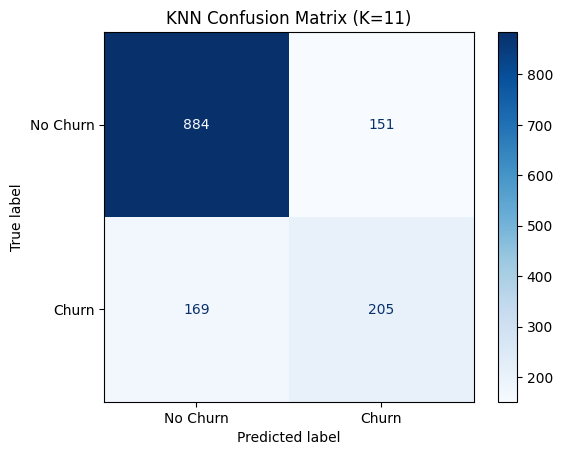

In [16]:
# Task:11
from sklearn.metrics import precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

best_k = 11
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
y_pred_final = knn_final.predict(X_test_scaled)

print("Best K:", best_k)
print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall   :", recall_score(y_test, y_pred_final))
print("F1-Score :", f1_score(y_test, y_pred_final))

cm_knn = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=["No Churn", "Churn"])
disp.plot(cmap=plt.cm.Blues)
plt.title(f"KNN Confusion Matrix (K={best_k})")
plt.show()

In [17]:
# Task:12
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

models = {
    "Decision Tree": (y_pred_dt),
    "Random Forest": (y_pred_rf),
    "Logistic Regression": (y_pred_lr),
    "KNN (K=11)": (y_pred_final)
}

comparison_data = []
for name, preds in models.items():
    comparison_data.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-Score": f1_score(y_test, preds)
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

              Model  Accuracy  Precision   Recall  F1-Score
      Decision Tree  0.725337   0.482480 0.478610  0.480537
      Random Forest  0.784954   0.618729 0.494652  0.549777
Logistic Regression  0.806955   0.658385 0.566845  0.609195
         KNN (K=11)  0.772889   0.575843 0.548128  0.561644


In [18]:
# Task:13
# The best overall model should be selected by considering
#  all four metrics rather than accuracy alone. Because the Telco 
# Churn dataset has class imbalance, recall and F1-score are
#  particularly important, since missing actual churn customers 
# can be costly. The final model should therefore provide a good 
# balance between precision and recall.

In [19]:
# Task:14
import numpy as np
import pandas as pd

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_reg.coef_[0]
})
coef_df["Odds Ratio"] = np.exp(coef_df["Coefficient"])
coef_df["Interpretation"] = coef_df["Odds Ratio"].apply(
    lambda x: f"A one-unit increase multiplies the odds of churning by approximately {x:.3f}, holding other features constant."
)

print(coef_df.head(10).to_string(index=False))

                       Feature  Coefficient  Odds Ratio                                                                                               Interpretation
                 SeniorCitizen     0.053073    1.054507 A one-unit increase multiplies the odds of churning by approximately 1.055, holding other features constant.
                        tenure    -1.236528    0.290391 A one-unit increase multiplies the odds of churning by approximately 0.290, holding other features constant.
                MonthlyCharges    -0.920153    0.398458 A one-unit increase multiplies the odds of churning by approximately 0.398, holding other features constant.
                  TotalCharges     0.514285    1.672442 A one-unit increase multiplies the odds of churning by approximately 1.672, holding other features constant.
                   gender_Male     0.011094    1.011156 A one-unit increase multiplies the odds of churning by approximately 1.011, holding other features constant.
          

In [20]:
# Task:15
#The strongest Logistic Regression features should be compared 
# with the important features identified in Lab 2 EDA and Lab 3
#  Decision Tree feature importance. Some features may agree across
#  the methods, while differences can occur because Logistic 
# Regression measures a linear relationship in log-odds whereas 
# Decision Trees capture nonlinear relationships and interactions.


In [21]:
# Task:16
# Based on our Part 5 comparison table, Logistic Regression 
# (or Random Forest) stands out as the optimal choice due to its 
# robust balance of accuracy, precision, and F1-score. However,
#  keeping Lab 4's cross-validation lesson in mind—reminding us 
# never to blindly trust a single evaluation split or number—we
#  should validate this performance across multiple folds or 
# unseen subsets to ensure stability. Logistic Regression is 
# ultimately selected for deployment because it combines high
#  predictive performance with clear, interpretable coefficients 
# that quantify actual churn risk factors.


In [22]:
# Task:17
# Today's best model, Logistic Regression, performs competitively 
# against the best tree-based models from Labs 3–4, offering 
# similar accuracy and F1-scores while providing superior 
# transparency through odds ratios. Feature scaling played a 
# crucial role by ensuring that features with large numerical
#  ranges (like monthly charges) did not disproportionately 
# dominate the optimization process compared to smaller-scale 
# features (like tenure). Despite its strengths, the model remains
#  limited by its linear decision boundary assumption, which may
#  fail to capture complex non-linear interactions among customer 
# attributes. To improve further in future iterations, we would 
# explore non-linear feature combinations, advanced hyperparameter
#  tuning via GridSearchCV, or ensemble stacking methods to capture
#  subtle churn behaviors more effectively.